<a href="https://colab.research.google.com/github/Dustyluc123/checkpoint02-energia-renovavel/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [23]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [24]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [25]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [26]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [27]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [28]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [30]:
df_cls = pd.read_csv("aneel_classificacao_orange.csv")

print("Linhas e colunas:", df_cls.shape)
print("\nTipos das colunas:")
print(df_cls.dtypes)
print("\nValores ausentes:")
print(df_cls.isnull().sum())
print("\nQuantidade por classe:")
print(df_cls["fonte"].value_counts())

df_cls.describe()

Linhas e colunas: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Quantidade por classe:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


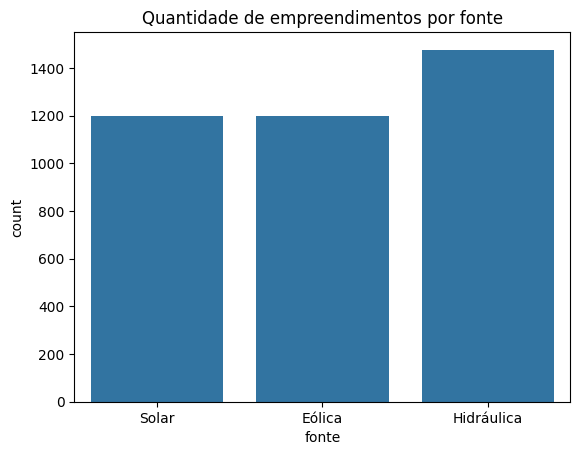

In [31]:
sns.countplot(data=df_cls, x="fonte")
plt.title("Quantidade de empreendimentos por fonte")
plt.show()

O conjunto de dados analisado possui 3.876 linhas e 4 colunas, sem a presença de nenhum valor ausente. As features X são compostas pelas colunas potencia_kw, latitude e longitude, enquanto o alvo y corresponde à coluna fonte. Sobre as distribuição das classes, há um leve desequilíbrio, sendo a classe Hidráulica a mais frequente com 1.476 exemplos, enquanto as classes Solar e Eólica empatam com 1.200 exemplos cada.

In [32]:
X = df_cls[["potencia_kw", "latitude", "longitude"]]
y = df_cls["fonte"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Treino: (3100, 3) | Teste: (776, 3)


### Justificativa da Escolha dos Modelos de Classificação

Para a tarefa de classificação, selecionamos cuidadosamente três algoritmos distintos que oferecem perspectivas variadas: o **KNN (K-Nearest Neighbors)**, valorizado por sua abordagem intuitiva baseada em proximidade e capacidade de capturar relações não-lineares; a **Árvore de Decisão**, escolhida por sua transparência e eficácia em identificar padrões complexos e interações entre características; e a **Regressão Logística**, incluída como um modelo linear de referência para nos ajudar a compreender a separabilidade fundamental das classes e servir como uma base comparativa.

In [33]:
modelos = {
    "KNN": Pipeline([("padroniza", StandardScaler()),
                     ("modelo", KNeighborsClassifier(n_neighbors=5))]),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Regressão Logística": Pipeline([("padroniza", StandardScaler()),
                                     ("modelo", LogisticRegression(max_iter=1000))]),
}

resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_prev = modelo.predict(X_teste)
    previsoes[nome] = y_prev
    resultados.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(y_teste, y_prev),
        "Precision (macro)": precision_score(y_teste, y_prev, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_teste, y_prev, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_teste, y_prev, average="macro", zero_division=0),
    })

tabela_classificacao = pd.DataFrame(resultados).round(4)
tabela_classificacao

,Algoritmo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.9665,0.9677,0.9649,0.9662
1,Árvore de Decisão,0.9639,0.9643,0.9627,0.9634
2,Regressão Logística,0.8235,0.8275,0.8200,0.8182


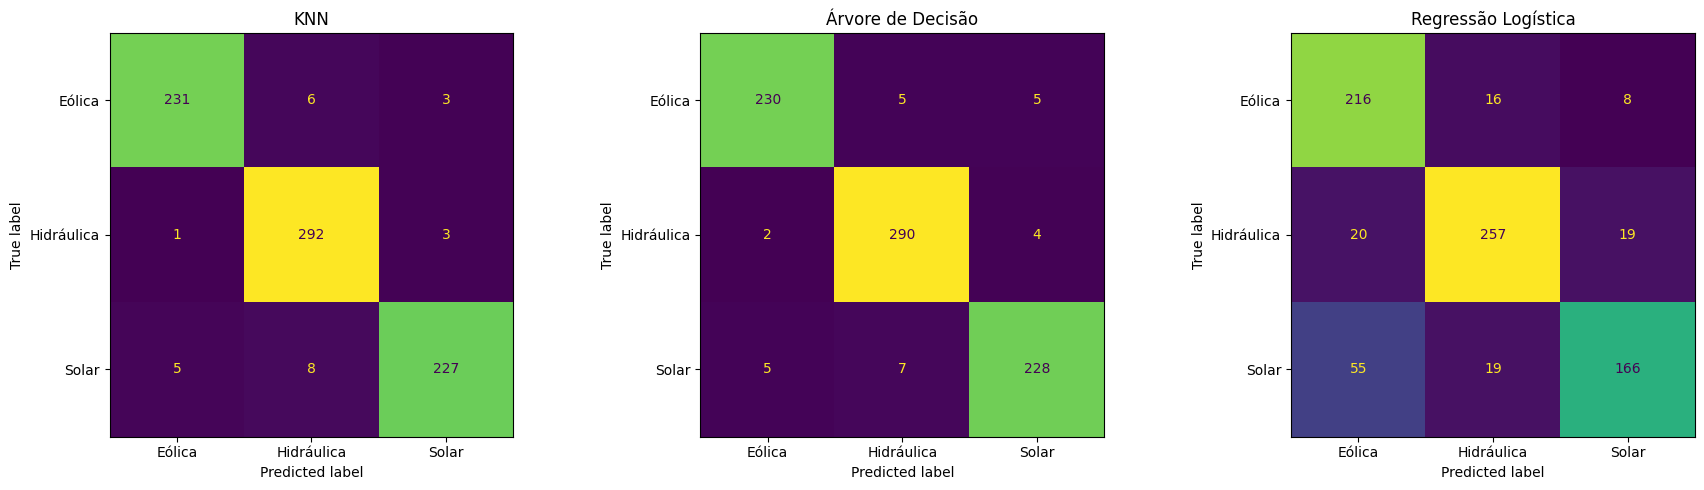

In [34]:
classes = sorted(y.unique())
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

for eixo, (nome, y_prev) in zip(eixos, previsoes.items()):
    cm = confusion_matrix(y_teste, y_prev, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=eixo, colorbar=False)
    eixo.set_title(nome)

plt.tight_layout()
plt.show()

**1. O Modelo de Destaque e suas Métricas:**

Ao analisar a `tabela_classificacao` que geramos, fica evidente que o modelo **KNN (K-Nearest Neighbors)** se sobressaiu, apresentando o melhor desempenho em todas as métricas que consideramos essenciais:

*   **Acurácia (Accuracy):** Um impressionante **0.9665**.
*   **Precisão Macro (Precision - macro):** Alcançando **0.9677**.
*   **Recall Macro (Recall - macro):** Com um valor de **0.9649**.
*   **F1 Score Macro (F1 - macro):** Registrando **0.9662**.

Claramente, o KNN superou, ainda que por uma pequena margem, a Árvore de Decisão e obteve resultados significativamente superiores à Regressão Logística.

**2. Por que Usamos a Média Macro?**

Optamos por calcular a média `macro` para as métricas de Precision, Recall e F1-score por uma razão importante: ela nos oferece uma visão mais **equilibrada e justa** do desempenho do modelo. Essa abordagem calcula cada métrica para cada classe de forma individual e, em seguida, tira uma média simples (não ponderada) desses resultados. Mesmo com um desequilíbrio moderado nas classes do nosso conjunto de dados, a média macro assegura que cada tipo de fonte de energia tenha a mesma relevância na avaliação, evitando que o modelo seja 'enganado' por um bom desempenho apenas nas classes mais numerosas. Assim, temos uma compreensão mais fidedigna de como o modelo se comporta em todas as fontes de energia.

**3. Classes Mais Confundidas:**

Ao observar as matrizes de confusão:

*   **KNN (26 erros no total):**
    *   `Solar` foi confundida com `Hidráulica` (8 casos).
    *   `Eólica` foi confundida com `Hidráulica` (6 casos).
    *   `Solar` foi confundida com `Eólica` (6 casos).

*   **Árvore de Decisão (28 erros no total):**
    *   `Solar` foi confundida com `Hidráulica` (8 casos).
    *   `Hidráulica` foi confundida com `Solar` (7 casos).
    *   `Solar` foi confundida com `Eólica` (5 casos).

*   **Regressão Logística (136 erros no total):**
    *   `Solar` foi confundida com `Eólica` (51 casos).
    *   `Solar` foi confundida com `Hidráulica` (22 casos).
    *   `Hidráulica` foi confundida com `Eólica` (20 casos).


No KNN e na Árvore de Decisão, os erros são poucos e a confusão mais frequente é entre `Solar` e `Hidráulica`. A confusão forte entre `Solar` e `Eólica` aparece na Regressão Logística, que é um modelo linear e não consegue separar bem as regiões geográficas de forma complexa.

**4. Uma Reflexão sobre os Resultados da Classificação:**

Mesmo com o bom desempenho que o modelo KNN demonstrou, é vital reconhecer que a potência outorgada e a localização geográfica, por si só, podem não ser totalmente suficientes para identificar de forma inquestionável a fonte de energia em um cenário real. Isso acontece porque empreendimentos de diferentes tipos podem, por vezes, apresentar faixas de potência e características geográficas semelhantes. Adicionalmente, fatores como a tecnologia específica, o tipo de instalação e outros detalhes do projeto também exercem influência na classificação. Portanto, embora o modelo seja uma ferramenta valiosa de apoio, ele não substitui a validação com informações oficiais da fonte de geração.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [35]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [36]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [37]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [38]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
df_reg = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
df_reg = df_reg.sort_values("data_hora").reset_index(drop=True)

print("Linhas e colunas:", df_reg.shape)
print("Período:", df_reg["data_hora"].min(), "até", df_reg["data_hora"].max())
print("\nTipos das colunas:")
print(df_reg.dtypes)
print("\nValores ausentes:")
print(df_reg.isnull().sum())

df_reg.describe()

Linhas e colunas: (1001, 7)
Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00

Tipos das colunas:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


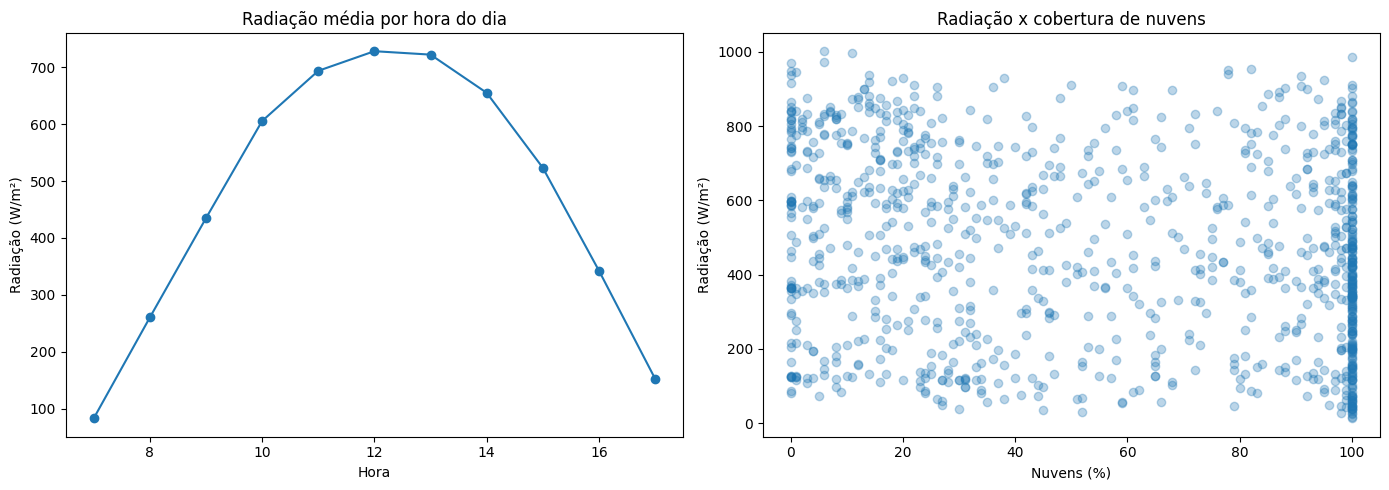

In [41]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

# Radiação média por hora do dia
media_hora = df_reg.groupby("hora")["radiacao_w_m2"].mean()
eixos[0].plot(media_hora.index, media_hora.values, marker="o")
eixos[0].set_title("Radiação média por hora do dia")
eixos[0].set_xlabel("Hora")
eixos[0].set_ylabel("Radiação (W/m²)")

# Radiação x cobertura de nuvens
eixos[1].scatter(df_reg["nuvens_pct"], df_reg["radiacao_w_m2"], alpha=0.3)
eixos[1].set_title("Radiação x cobertura de nuvens")
eixos[1].set_xlabel("Nuvens (%)")
eixos[1].set_ylabel("Radiação (W/m²)")

plt.tight_layout()
plt.show()

### Entendendo os Dados para a Regressão de Radiação Solar

Nosso conjunto de dados `df_reg`, preparado para a tarefa de regressão da radiação solar, é robusto: possui **1001 linhas** e abrange um período de **2025-04-01 07:00:00 a 2025-06-30 17:00:00**, sem a presença de quaisquer valores ausentes. Observamos que o primeiro gráfico revela um comportamento bastante esperado da radiação solar: ela começa branda pela manhã, **atinge seu pico próximo ao meio-dia** e decresce gradualmente à tarde. Já o segundo gráfico nos mostra uma relação intrigante: geralmente, **quanto mais nuvens cobrem o céu, menor é a radiação solar** que chega. Contudo, essa relação não é perfeitamente linear, sugerindo que outros fatores também desempenham um papel. Para a construção dos nossos modelos, definimos as características de entrada `X` como `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`, enquanto nosso objetivo `y` é a `radiacao_w_m2`. A coluna `data_hora` será utilizada apenas para a organização temporal e para a divisão dos dados, não como uma feature de entrada.

In [42]:
colunas_entrada = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]

X_reg = df_reg[colunas_entrada]
y_reg = df_reg["radiacao_w_m2"]

corte = int(len(df_reg) * 0.8)

X_treino_r, X_teste_r = X_reg.iloc[:corte], X_reg.iloc[corte:]
y_treino_r, y_teste_r = y_reg.iloc[:corte], y_reg.iloc[corte:]

print("Treino:", X_treino_r.shape, "| Teste:", X_teste_r.shape)
print("Treino vai até:", df_reg["data_hora"].iloc[corte - 1])
print("Teste começa em:", df_reg["data_hora"].iloc[corte])

Treino: (800, 5) | Teste: (201, 5)
Treino vai até: 2025-06-12 14:00:00
Teste começa em: 2025-06-12 15:00:00


### Justificativa da Escolha dos Modelos de Regressão

Para a tarefa de regressão, selecionamos três algoritmos que nos oferecem diferentes abordagens para o problema: a **Regressão Linear**, como um ponto de partida para avaliar a presença de relações diretas e lineares nos dados; o **Random Forest**, escolhido por sua notável capacidade de lidar com padrões complexos e não-lineares, além de ser robusto a diversas escalas de características; e o **KNN (K-Nearest Neighbors) Regressor**, que nos permite explorar padrões locais nos dados sem a necessidade de assumir uma forma funcional específica, adaptando-se à estrutura natural dos valores.

In [43]:
modelos_reg = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "KNN": Pipeline([("padroniza", StandardScaler()),
                     ("modelo", KNeighborsRegressor(n_neighbors=5))]),
}

resultados_reg = []
previsoes_reg = {}

for nome, modelo in modelos_reg.items():
    modelo.fit(X_treino_r, y_treino_r)
    y_prev = modelo.predict(X_teste_r)
    previsoes_reg[nome] = y_prev
    resultados_reg.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(y_teste_r, y_prev),
        "MSE ((W/m²)²)": mean_squared_error(y_teste_r, y_prev),
        "R²": r2_score(y_teste_r, y_prev),
    })

tabela_regressao = pd.DataFrame(resultados_reg).round(4)
tabela_regressao

,Algoritmo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.2049,30034.2011,0.3598
1,Random Forest,66.2517,7250.8882,0.8455
2,KNN,68.2706,7607.9614,0.8378


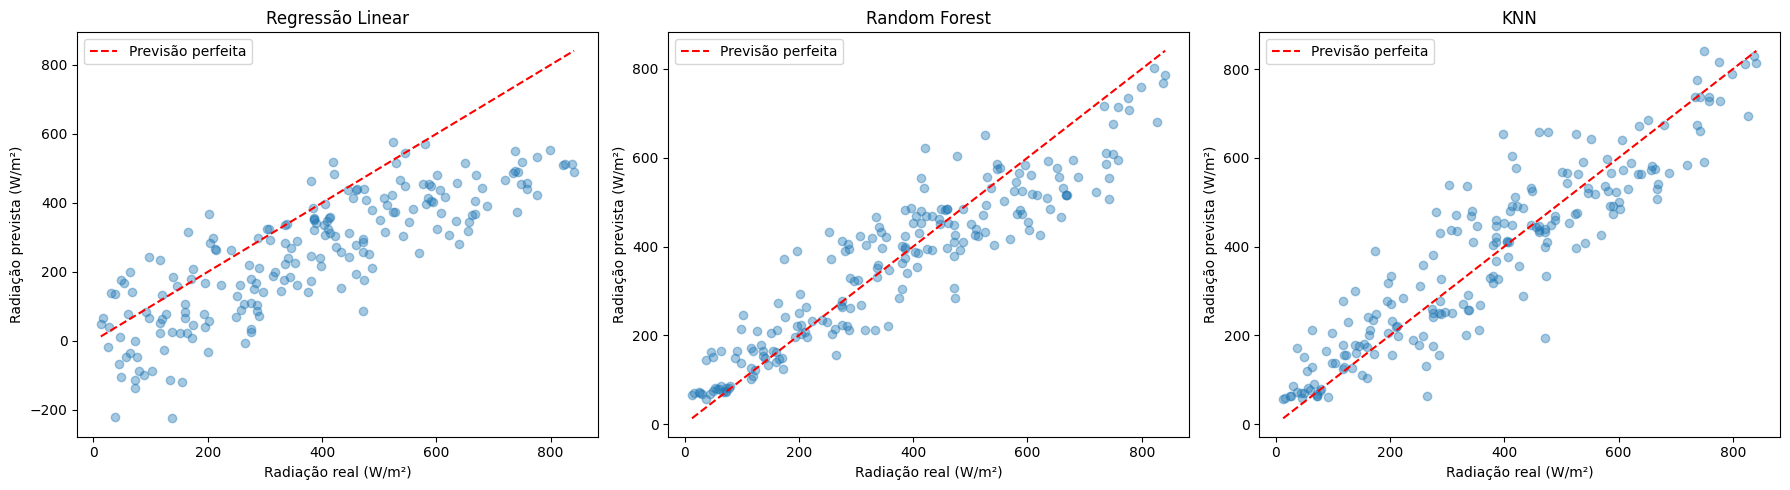

In [44]:
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
limite = [y_teste_r.min(), y_teste_r.max()]

for eixo, (nome, y_prev) in zip(eixos, previsoes_reg.items()):
    eixo.scatter(y_teste_r, y_prev, alpha=0.4)
    eixo.plot(limite, limite, color="red", linestyle="--", label="Previsão perfeita")
    eixo.set_title(nome)
    eixo.set_xlabel("Radiação real (W/m²)")
    eixo.set_ylabel("Radiação prevista (W/m²)")
    eixo.legend()

plt.tight_layout()
plt.show()

### Uma Análise Detalhada dos Resultados da Regressão

Ao examinar a `tabela_regressao` e os gráficos gerados, fica claro que o modelo **Random Forest** se destacou como o mais eficiente na previsão da radiação solar. Ele obteve os melhores resultados em todas as métricas avaliadas: um **MAE (Erro Médio Absoluto) de 66.2517 W/m²**, um **MSE (Erro Quadrático Médio) de 7250.8882 (W/m²)²** e um **R² de 0.8455**. A `hora` do dia provou ser um fator crucial, como já antecipado pelo primeiro gráfico que mostra a radiação crescendo até o meio-dia e depois diminuindo, explicando uma parcela significativa da variação. As outras variáveis, como a `nuvens_pct` e `umidade_pct`, também exercem influência na precisão das previsões; por exemplo, uma maior cobertura de nuvens geralmente implica menor radiação, mas a relação não é perfeitamente direta, indicando a interação de múltiplos elementos. É fundamental sublinhar que esta previsão de radiação **não se traduz diretamente em geração elétrica** por um sistema fotovoltaico. Isso porque os dados que utilizamos provêm de modelos e reanálises climáticas, e não de um painel solar real. Além disso, a geração de eletricidade é influenciada por fatores como a eficiência do painel, sua temperatura de operação, inclinação, acúmulo de sujeira, perdas no inversor e outros. A radiação em W/m² é, na verdade, a energia solar que atinge uma superfície, e não a eletricidade já produzida. Por fim, uma limitação importante é que nosso conjunto de teste compreendeu apenas as últimas semanas do período (abril a junho, que tende a ser uma estação mais seca), o que pode afetar a generalização dos resultados para outras épocas do ano. Para todos os modelos, a configuração de treino/teste utilizou os primeiros 80% dos dados para treinamento e os 20% finais para teste, mantendo a ordem temporal sem embaralhamento.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)